In [1]:
library(Signac)
library(Seurat)
library(ggplot2)
library(future)

plan("multicore", workers = 12)
options(future.globals.maxSize = 100000 * 1024^3)

set.seed(1234)

The legacy packages maptools, rgdal, and rgeos, underpinning this package
will retire shortly. Please refer to R-spatial evolution reports on
https://r-spatial.org/r/2023/05/15/evolution4.html for details.
This package is now running under evolution status 0 

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, saveRDS


Loading Seurat v5 beta version 
To maintain compatibility with previous workflows, new Seurat objects will use the previous object structure by default
To use new Seurat v5 assays: Please run: options(Seurat.object.assay.version = 'v5')



In [2]:
atac <- readRDS('data/atac_common_peak_set_dmg_atlas_qc_filtered_dbl_scores_merged.rds')
multiome <- readRDS('data/multiome_common_peak_set_dmg_atlas_qc_filtered_dbl_scores_merged.rds')

In [3]:
# first add dataset-identifying metadata
atac$dataset <- "ATAC"
multiome$dataset <- "Multiome"

# merge
dmg <- merge(atac, multiome)

# process the combined dataset
dmg <- FindTopFeatures(dmg, min.cutoff = 10)
dmg <- RunTFIDF(dmg)
dmg <- RunSVD(dmg)
dmg <- RunUMAP(dmg, reduction = "lsi", dims = 2:30)
p1 <- DimPlot(dmg, group.by = "dataset")

Performing TF-IDF normalization

Running SVD

Scaling cell embeddings

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
08:25:13 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by ‘spam’

08:25:13 Read 143344 rows and found 29 numeric columns

08:25:13 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by ‘spam’

08:25:13 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*

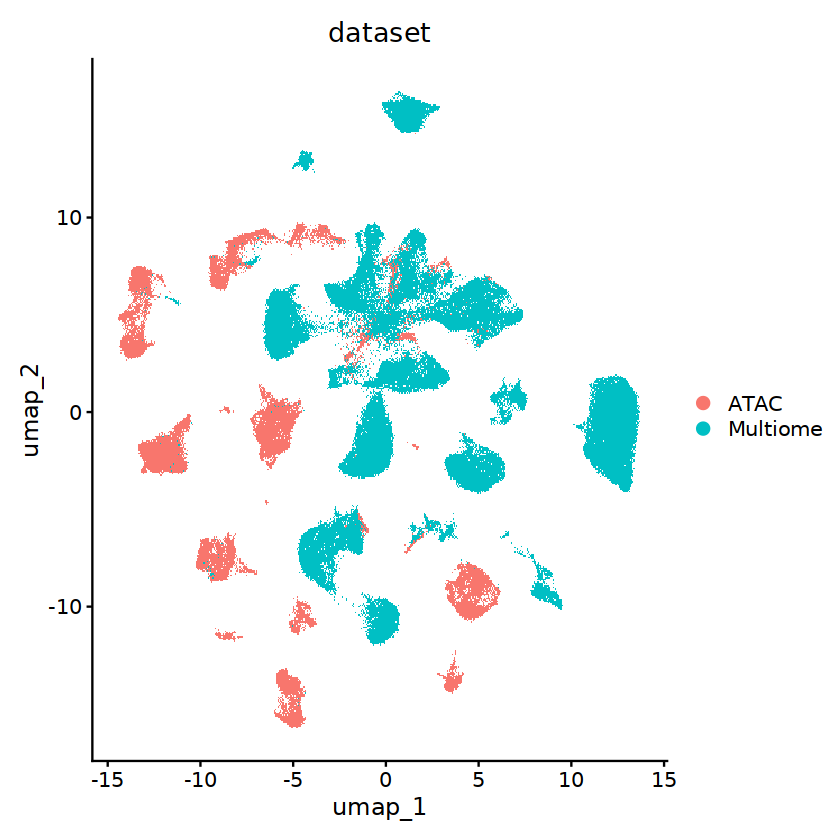

In [4]:
p1

In [5]:
dmg

An object of class Seurat 
378298 features across 143344 samples within 1 assay 
Active assay: ATAC (378298 features, 378298 variable features)
 2 layers present: counts, data
 2 dimensional reductions calculated: lsi, umap

### Integration

In [6]:
# compute LSI
atac <- FindTopFeatures(atac, min.cutoff = 10)
atac <- RunTFIDF(atac)
atac <- RunSVD(atac)

Performing TF-IDF normalization

Warning message in RunTFIDF.default(object = GetAssayData(object = object, slot = "counts"), :
“Some features contain 0 total counts”
Running SVD

Scaling cell embeddings



In [7]:
# compute LSI
multiome <- FindTopFeatures(multiome, min.cutoff = 10)
multiome <- RunTFIDF(multiome)
multiome <- RunSVD(multiome)

Performing TF-IDF normalization

Running SVD

Scaling cell embeddings



In [8]:
# find integration anchors
integration.anchors <- FindIntegrationAnchors(
  object.list = list(multiome, atac),
  anchor.features = rownames(multiome),
  reduction = "rlsi",
  dims = 2:30
)

# integrate LSI embeddings
integrated <- IntegrateEmbeddings(
  anchorset = integration.anchors,
  reductions = dmg[["lsi"]],
  new.reduction.name = "integrated_lsi",
  dims.to.integrate = 1:30
)

# create a new UMAP using the integrated embeddings
integrated <- RunUMAP(integrated, reduction = "integrated_lsi", dims = 2:30)
p2 <- DimPlot(integrated, group.by = "dataset")

Computing within dataset neighborhoods

Finding all pairwise anchors

Warning message:
“`invoke()` is deprecated as of rlang 0.4.0.
Please use `exec()` or `inject()` instead.
This warning is displayed once every 8 hours.”
Converting layer counts in assay ATAC to empty dgCMatrix

Converting layer counts in assay ATAC to empty dgCMatrix

Warning message:
“No filtering performed if passing to data rather than counts”
Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 5028 anchors

Warning message:
“`invoke()` is deprecated as of rlang 0.4.0.
Please use `exec()` or `inject()` instead.
This warning is displayed once every 8 hours.”
Merging dataset 2 into 1

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

08:59:52 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined 

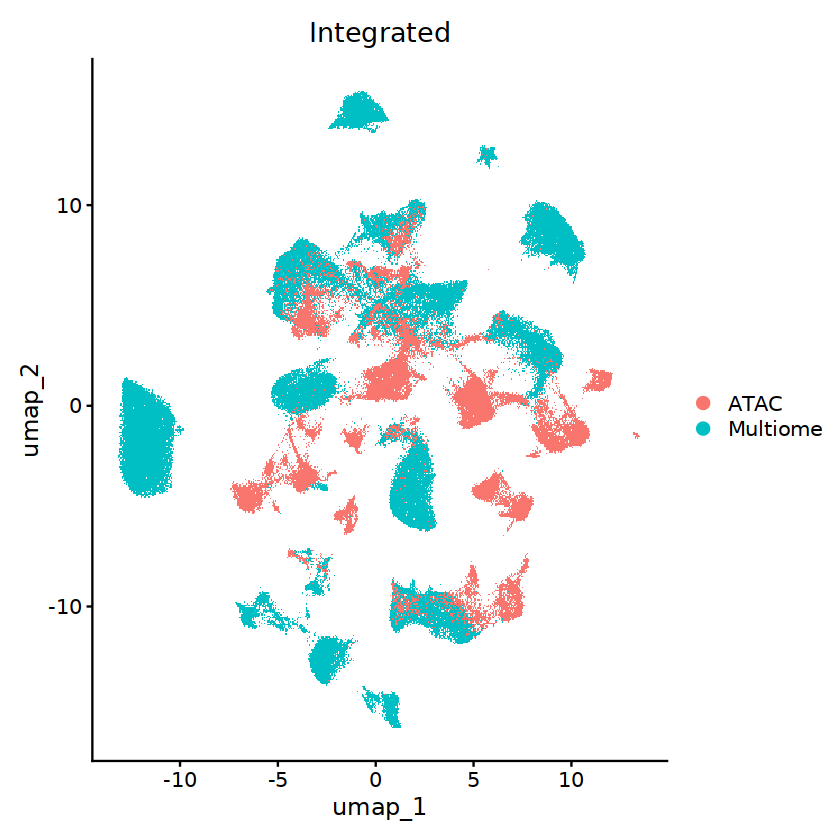

In [9]:
p2 + ggtitle("Integrated")

In [10]:
rm(atac)
rm(multiome)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,8418660,449.7,14211632,759.0,14211632,759.0
Vcells,9120415066,69583.3,20894775873,159414.5,16898630968,128926.4


### Create a gene activity matrix

In [12]:
gene.activities <- GeneActivity(integrated)

Extracting gene coordinates

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extra

In [13]:
# add the gene activity matrix to the Seurat object as a new assay and normalize it
integrated[['RNA']] <- CreateAssayObject(counts = gene.activities)
integrated <- NormalizeData(
  object = integrated,
  assay = 'RNA',
  normalization.method = 'LogNormalize',
  scale.factor = median(integrated$nCount_RNA)
)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



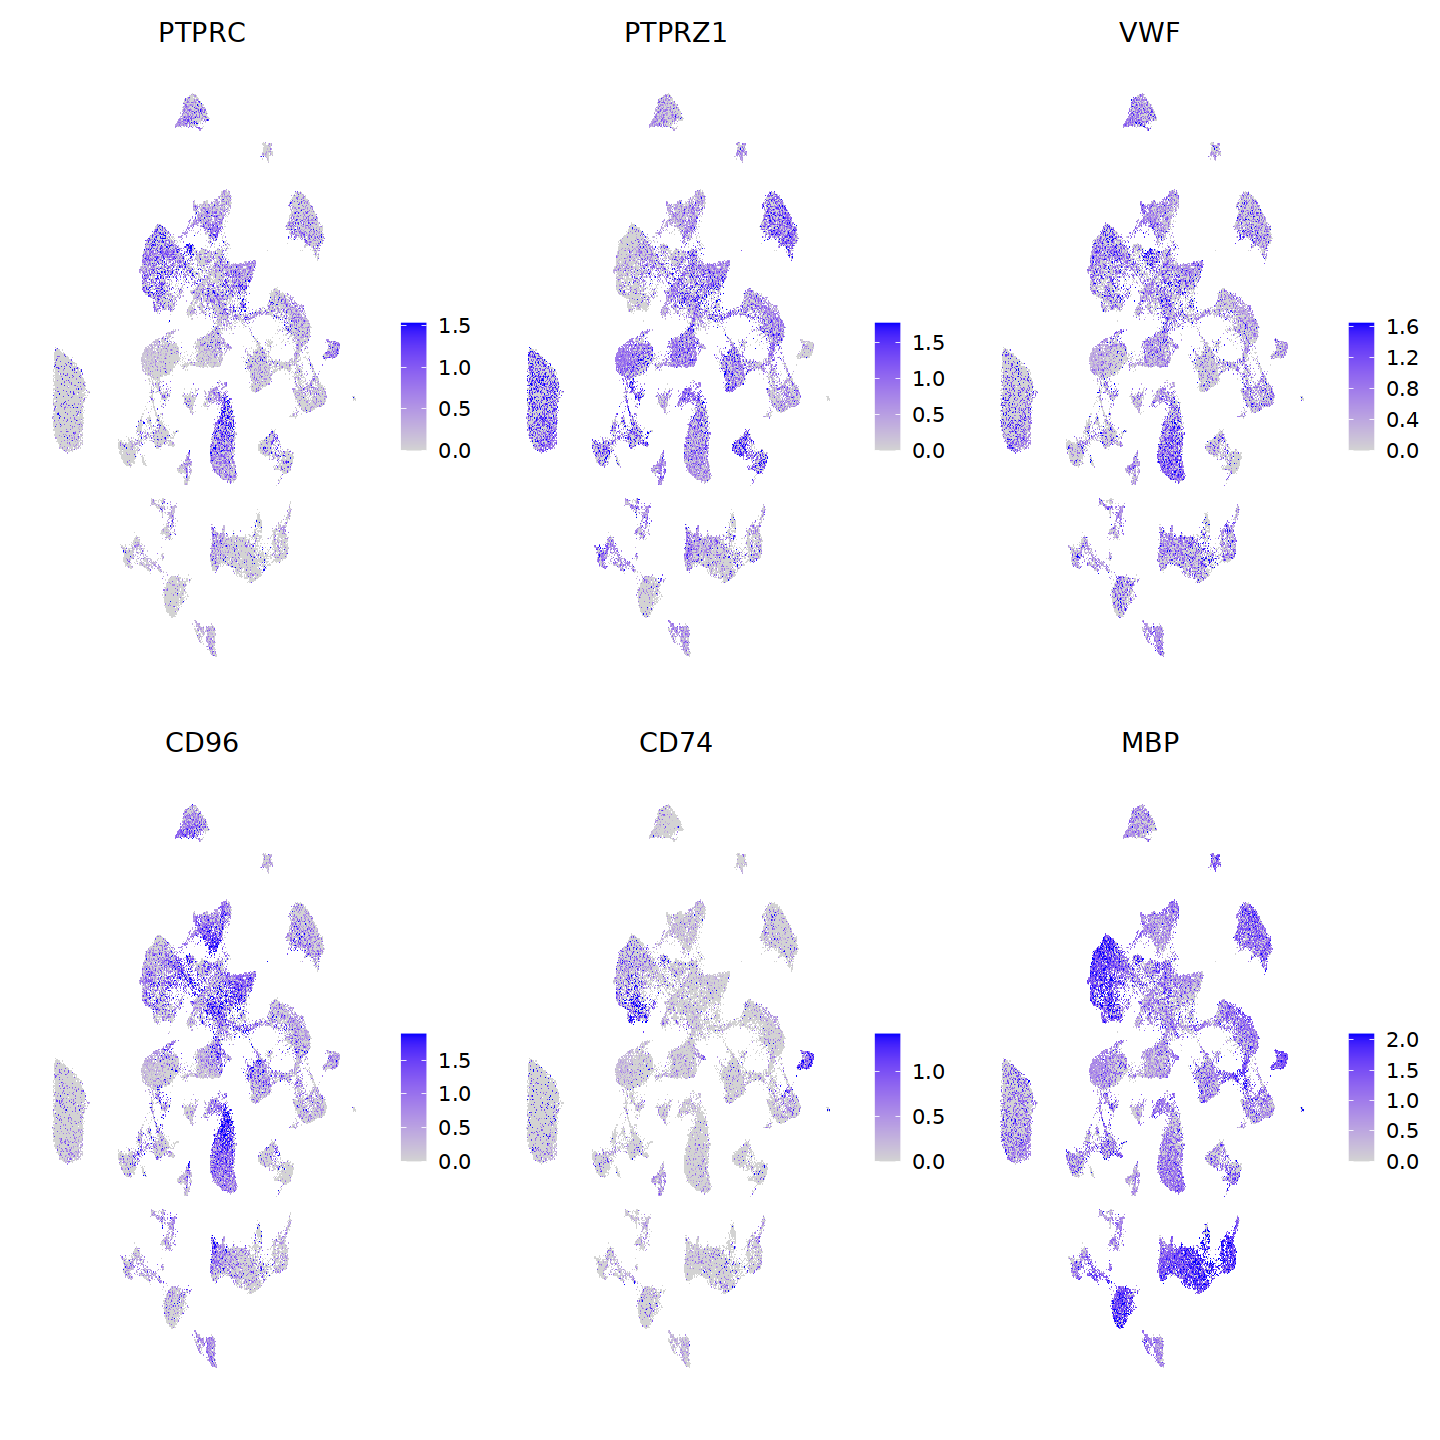

In [14]:
DefaultAssay(integrated) <- 'RNA'

  options(repr.plot.height = 12, repr.plot.width = 12)
FeaturePlot(
  object = integrated,
  features = c('PTPRC', 'PTPRZ1', 'VWF', 'CD96', 'CD74', 'MBP'),
  pt.size = 0.1,
  max.cutoff = 'q95',
  ncol = 3
) & NoAxes()

### Integrating with scRNA-seq data

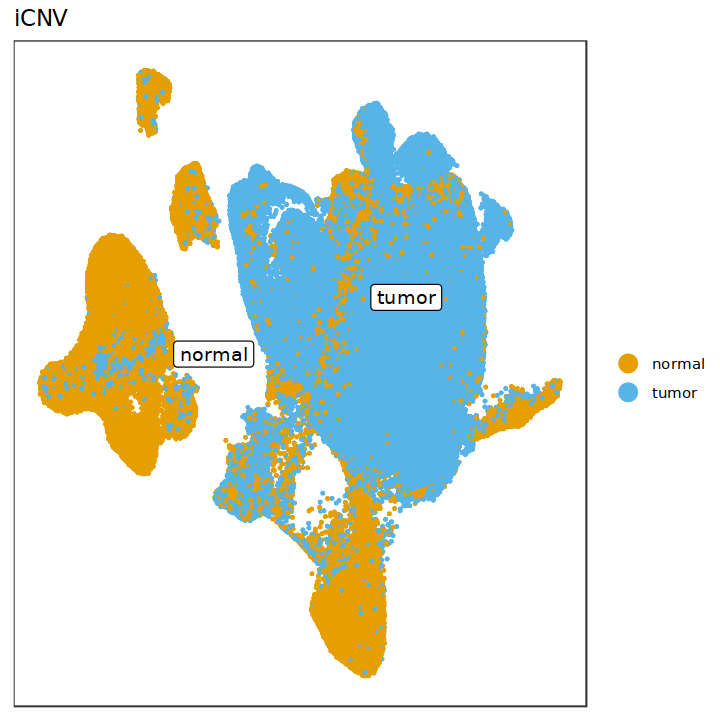

In [16]:
dmg_rna <- readRDS("/projects/0/einf2548/cruiz/dmg/data/merged_dmg_atlas_qc_filtered.rds")

dmg_rna <- AddMetaData(dmg_rna, readRDS('/projects/0/einf2548/cruiz/dmg/data/iCNV_dmg_atlas.rds'))
dmg_rna$iCNV <- dplyr::recode(dmg_rna$iCNV, 
                  filtered = 'tumor',
                  Unknown = 'normal')

options(repr.plot.height = 6, repr.plot.width = 6)
dittoSeq::dittoDimPlot(dmg_rna, 
             reduction.use = "umap", var = "iCNV", 
             do.label = T, labels.size = 4, 
             do.raster = TRUE) + NoAxes() 

dmg_rna$cell_id <- paste0(dmg_rna$predicted.annotation_level_3, '_', dmg_rna$iCNV)

In [17]:
dmg_rna$cell_id <- dplyr::recode(dmg_rna$cell_id,
                  `NPC-like_normal` = 'Stem_like_normal', 
                   `OPC_normal` = 'Stem_like_normal', 
                   `OPC-like_normal` = 'Stem_like_normal', 
                   `Endothelial_normal` = 'Endothelial', 
                   `TAM-BDM_normal` = 'TAM_BDM', 
                   `Mono_normal` = 'Mono', 
                   `Oligodendrocyte_normal` = 'Oligodendrocyte', 
                   `CD4/CD8_normal` = 'CD4_CD8', 
                   `MES-like_normal` = 'Differentiated_like_normal', 
                   `TAM-MG_normal` = 'TAM_MG', 
                   `B cell_normal` = 'B_cell', 
                   `DC_normal` = 'DC', 
                   `Mural cell_normal` = "Mural_cell", 
                   `Endothelial_tumor` = 'Endothelial', 
                   `TAM-BDM_tumor` = 'TAM_BDM', 
                   `Mono_tumor` = 'Mono', 
                   `Plasma B_normal` = 'Plasma', 
                   `Oligodendrocyte_tumor` = 'Oligodendrocyte', 
                   `Mural cell_tumor` = 'Mural_cell', 
                   `Plasma B_tumor` = 'Plasma', 
                   `MES-like_tumor`  = 'Differentiated_like_tumor', 
                   `CD4/CD8_tumor` = 'CD4_CD8', 
                   `OPC-like_tumor` = 'Stem_like_tumor', 
                   `AC-like_tumor` = 'Differentiated_like_tumor', 
                   `NPC-like_tumor` = 'Stem_like_tumor', 
                   `AC-like_normal` = 'Differentiated_like_normal', 
                   `TAM-MG_tumor` = 'TAM_MG', 
                   `B cell_tumor` = 'B_cell', 
                   `OPC_tumor` = 'Stem_like_tumor', 
                   `Neuron_normal` = 'Neuron', 
                   `Mast_tumor` = 'Mast', 
                   `Astrocyte_tumor` = 'Differentiated_like_tumor', 
                   `Neuron_tumor` = 'Neuron', 
                   `Astrocyte_normal` = 'Differentiated_like_normal', 
                   `DC_tumor` = 'DC', 
                   `Mast_normal` = 'Mast',
                   `NK_normal` = 'CD4_CD8')

In [18]:
colors <- structure(dittoSeq::dittoColors()[1:length(names(table(dmg_rna$cell_id)))],
                   names = names(table(dmg_rna$cell_id)))
colors

B_cell                    CD4_CD8 
                 "#E69F00"                  "#56B4E9" 
                        DC Differentiated_like_normal 
                 "#009E73"                  "#F0E442" 
 Differentiated_like_tumor                Endothelial 
                 "#0072B2"                  "#D55E00" 
                      Mast                       Mono 
                 "#CC79A7"                  "#666666" 
                Mural_cell                     Neuron 
                 "#AD7700"                  "#1C91D4" 
           Oligodendrocyte                     Plasma 
                 "#007756"                  "#D5C711" 
          Stem_like_normal            Stem_like_tumor 
                 "#005685"                  "#A04700" 
                   TAM_BDM                     TAM_MG 
                 "#B14380"                  "#4D4D4D"

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



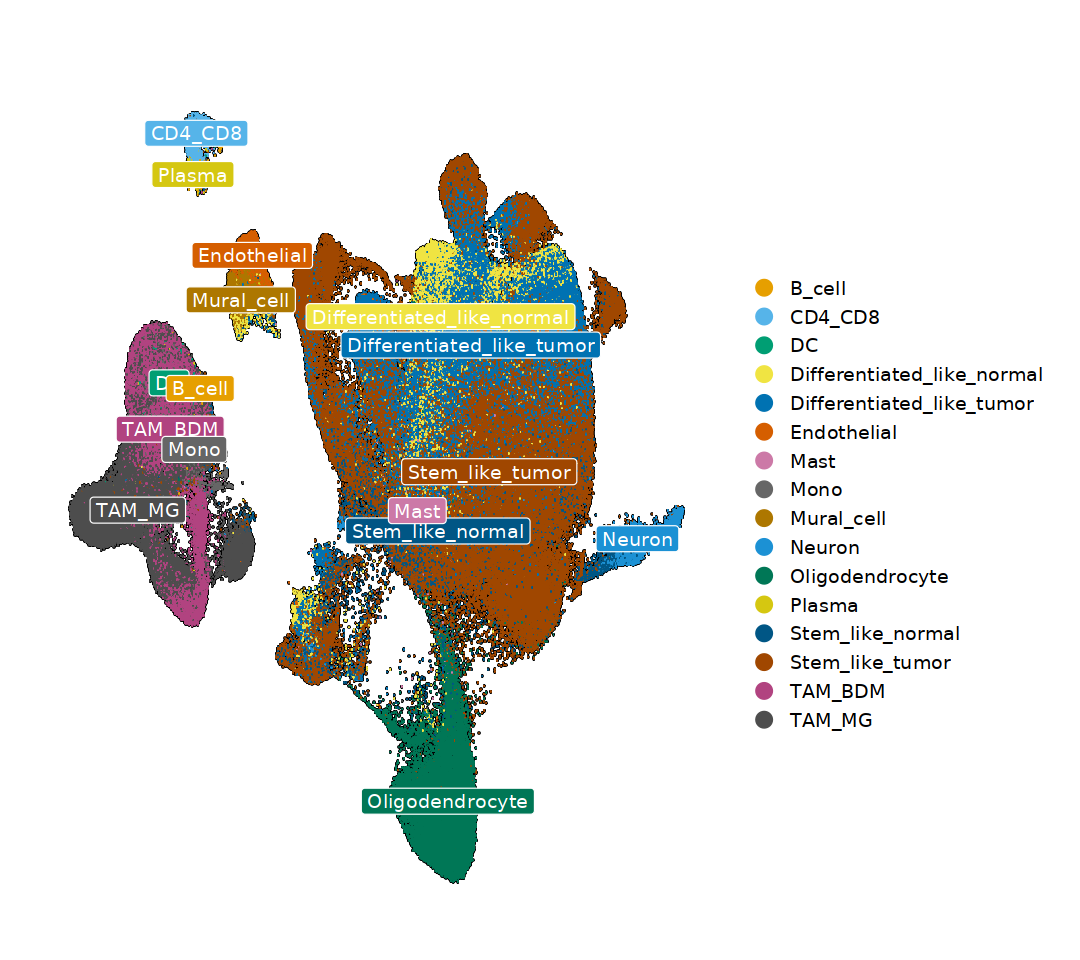

In [19]:
options(repr.plot.height = 8, repr.plot.width = 9)
SCpubr::do_DimPlot(dmg_rna, 
                   colors.use = colors,
                   legend.position = "right",
                     group.by = "cell_id", 
                     label = T,
                     raster = TRUE)

In [20]:
n_cells <- nrow(dmg_rna@meta.data)
n_sample <- round(n_cells * 0.3)
sampled_cells <- sample(Cells(dmg_rna), n_sample)
subset_dmg <- subset(dmg_rna, cells = sampled_cells)
subset_dmg

An object of class Seurat 
38576 features across 122868 samples within 6 assays 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 5 other assays present: RAW, prediction.score.annotation_level_1, prediction.score.annotation_level_2, prediction.score.annotation_level_3, prediction.score.annotation_level_4
 4 dimensional reductions calculated: pca, umap, ref.pca, ref.umap

In [21]:
rm(dmg_rna)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,11145047,595.3,20395044,1089.3,20395044,1089.3
Vcells,19918624051,151967.1,30088653256,229558.3,20888360267,159365.6


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



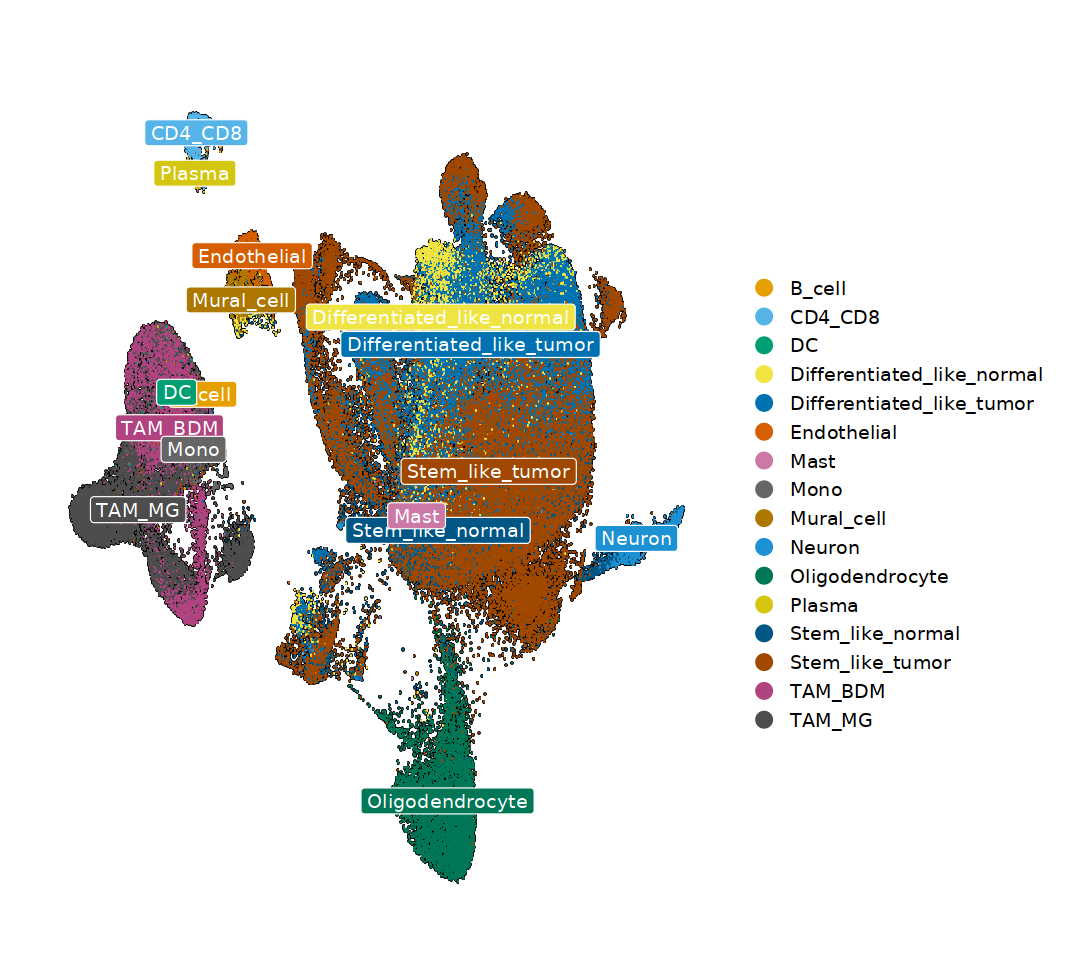

In [22]:
options(repr.plot.height = 8, repr.plot.width = 9)
SCpubr::do_DimPlot(subset_dmg, 
                   colors.use = colors,
                   legend.position = "right",
                     group.by = "cell_id", 
                     label = T,
                     raster = TRUE)

In [ ]:
transfer.anchors <- FindTransferAnchors(
  reference = subset_dmg,
  query = integrated,
  reduction = 'cca'
)

Running CCA



In [ ]:
predicted.labels.broad <- TransferData(
  anchorset = transfer.anchors,
  refdata = subset_dmg$cell_id,
  weight.reduction = integrated[['integrated_lsi']],
  dims = 2:30
)

predicted.labels.broad

In [ ]:
predicted.labels.fine <- TransferData(
  anchorset = transfer.anchors,
  refdata = subset_dmg$predicted.annotation_level_3,
  weight.reduction = integrated[['integrated_lsi']],
  dims = 2:30
)

predicted.labels.fine

In [ ]:
integrated@misc$predicted.labels.fine <- predicted.labels.fine

In [ ]:
integrated <- AddMetaData(object = integrated, metadata = predicted.labels.broad)

In [ ]:
plot1 <- DimPlot(
  object = subset_dmg,
    cols = dittoSeq::dittoColors(),
  group.by = 'cell_id',
  # label = TRUE,
  repel = TRUE) + NoAxes() + ggtitle('scRNA-seq')

plot2 <- DimPlot(
  object = integrated,
    cols = dittoSeq::dittoColors(),
  group.by = 'predicted.id',
  # label = TRUE,
  repel = TRUE) + NoAxes() + ggtitle('scATAC-seq')

options(repr.plot.height = 6, repr.plot.width = 14)
plot1 + plot2

In [ ]:
options(repr.plot.height = 20, repr.plot.width = 20)
dittoSeq::dittoDimPlot(integrated, 
             reduction.use = "umap", 
             split.by = "predicted.id", 
             var = "predicted.id", 
             size = 0.5)

In [ ]:
saveRDS(integrated, 'data/cca_integrated_atac_multiome_dmg_atlas.rds')

### RNA imputation

In [ ]:
# predict gene expression values
rna <- TransferData(
  anchorset = transfer.anchors,
  refdata = GetAssayData(subset_dmg, assay = "RNA", slot = "data"),
  weight.reduction = integrated[["integrated_lsi"]],
  dims = 2:30
)

# add predicted values as a new assay
integrated[["predicted"]] <- rna

In [ ]:
DefaultAssay(integrated) <- 'predicted'

  options(repr.plot.height = 12, repr.plot.width = 12)
FeaturePlot(
  object = integrated,
  features = c('PTPRC', 'PTPRZ1', 'VWF', 'CD96', 'CD74', 'MBP'),
  pt.size = 0.1,
  max.cutoff = 'q95',
  ncol = 3
) & NoAxes()

In [2]:
integrated <- readRDS('data/cca_integrated_atac_multiome_dmg_atlas.rds')
integrated

An object of class Seurat 
397376 features across 143344 samples within 2 assays 
Active assay: RNA (19607 features, 0 variable features)
 2 layers present: counts, data
 1 other assay present: ATAC
 2 dimensional reductions calculated: integrated_lsi, umap

In [3]:
colors <- structure(dittoSeq::dittoColors()[1:length(names(table(integrated$predicted.id)))],
                   names = names(table(integrated$predicted.id)))
colors

CD4_CD8 Differentiated_like_normal 
                 "#E69F00"                  "#56B4E9" 
 Differentiated_like_tumor                Endothelial 
                 "#009E73"                  "#F0E442" 
                      Mono                 Mural_cell 
                 "#0072B2"                  "#D55E00" 
                    Neuron            Oligodendrocyte 
                 "#CC79A7"                  "#666666" 
          Stem_like_normal            Stem_like_tumor 
                 "#AD7700"                  "#1C91D4" 
                   TAM_BDM                     TAM_MG 
                 "#007756"                  "#D5C711"

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



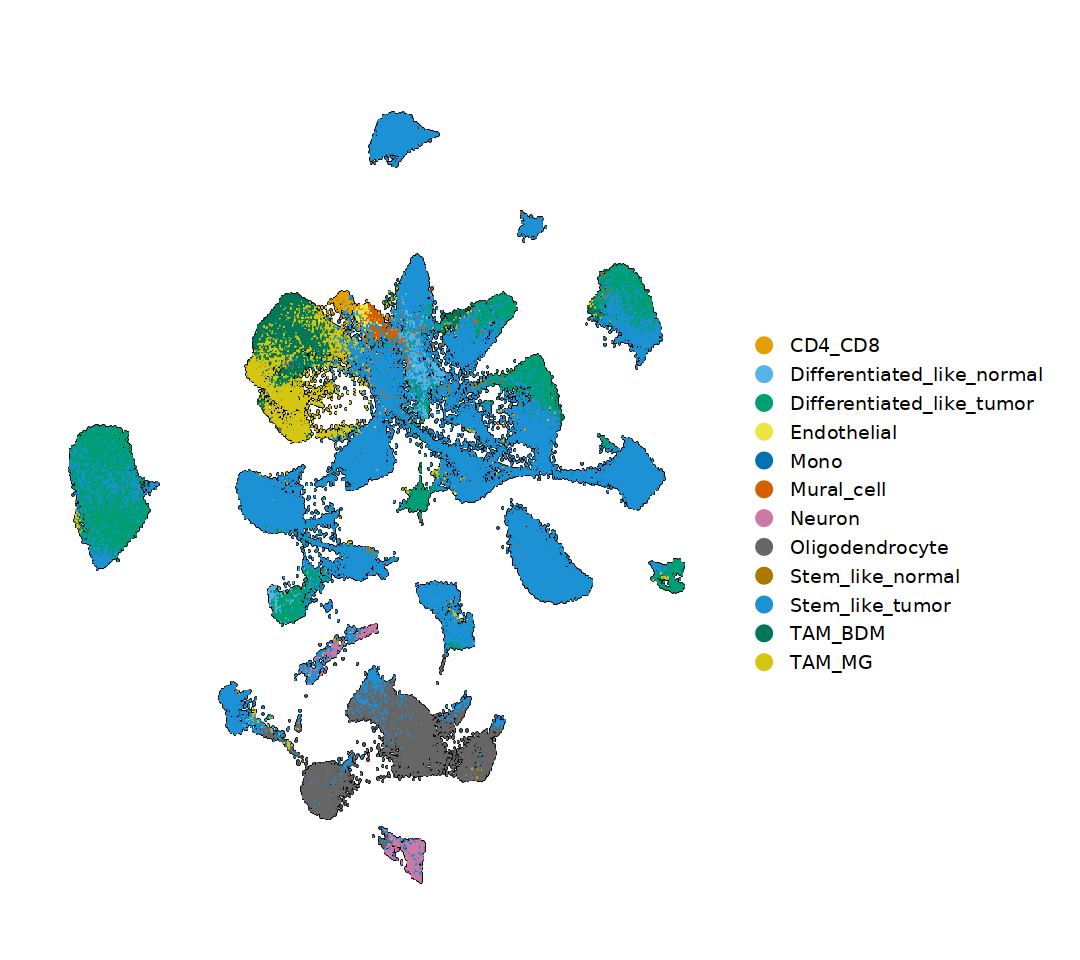

In [5]:
options(repr.plot.height = 8, repr.plot.width = 9)
SCpubr::do_DimPlot(integrated, 
                   colors.use = colors,
                   legend.position = "right",
                     group.by = "predicted.id", 
                     label = F,
                     raster = TRUE)

In [6]:
colnames(integrated@meta.data)

[1] "orig.ident"                                 
 [2] "gex_barcode"                                
 [3] "atac_barcode"                               
 [4] "is_cell"                                    
 [5] "excluded_reason"                            
 [6] "gex_raw_reads"                              
 [7] "gex_mapped_reads"                           
 [8] "gex_conf_intergenic_reads"                  
 [9] "gex_conf_exonic_reads"                      
[10] "gex_conf_intronic_reads"                    
[11] "gex_conf_exonic_unique_reads"               
[12] "gex_conf_exonic_antisense_reads"            
[13] "gex_conf_exonic_dup_reads"                  
[14] "gex_exonic_umis"                            
[15] "gex_conf_intronic_unique_reads"             
[16] "gex_conf_intronic_antisense_reads"          
[17] "gex_conf_intronic_dup_reads"                
[18] "gex_intronic_umis"                          
[19] "gex_conf_txomic_unique_reads"               
[20] "gex_umis_count"                             
[21] "gex_genes_count"                            
[22] "atac_raw_reads"                             
[23] "atac_unmapped_reads"                        
[24] "atac_lowmapq"                               
[25] "atac_dup_reads"                             
[26] "atac_chimeric_reads"                        
[27] "atac_mitochondrial_reads"                   
[28] "passed_filters"                             
[29] "atac_TSS_fragments"                         
[30] "atac_peak_region_fragments"                 
[31] "atac_peak_region_cutsites"                  
[32] "nCount_ATAC"                                
[33] "nFeature_ATAC"                              
[34] "SampleID"                                   
[35] "nucleosome_signal"                          
[36] "nucleosome_percentile"                      
[37] "TSS.enrichment"                             
[38] "TSS.percentile"                             
[39] "pct_reads_in_peaks"                         
[40] "blacklist_ratio"                            
[41] "high.tss"                                   
[42] "nucleosome_group"                           
[43] "scDblFinder.score"                          
[44] "scDblFinder.class"                          
[45] "p.value"                                    
[46] "q.value"                                    
[47] "scDblFinder.p"                              
[48] "combined"                                   
[49] "dataset"                                    
[50] "total"                                      
[51] "duplicate"                                  
[52] "chimeric"                                   
[53] "unmapped"                                   
[54] "lowmapq"                                    
[55] "mitochondrial"                              
[56] "nonprimary"                                 
[57] "is__cell_barcode"                           
[58] "TSS_fragments"                              
[59] "DNase_sensitive_region_fragments"           
[60] "enhancer_region_fragments"                  
[61] "promoter_region_fragments"                  
[62] "on_target_fragments"                        
[63] "blacklist_region_fragments"                 
[64] "peak_region_fragments"                      
[65] "peak_region_cutsites"                       
[66] "nCount_RNA"                                 
[67] "nFeature_RNA"                               
[68] "predicted.id"                               
[69] "prediction.score.NPC.like"                  
[70] "prediction.score.TAM.BDM"                   
[71] "prediction.score.OPC.like"                  
[72] "prediction.score.CD4.CD8"                   
[73] "prediction.score.MES.like"                  
[74] "prediction.score.Oligodendrocyte"           
[75] "prediction.score.TAM.MG"                    
[76] "prediction.score.OPC"                       
[77] "prediction.score.DC"                        
[78] "prediction.score.Mono"                      
[79] "prediction.score.

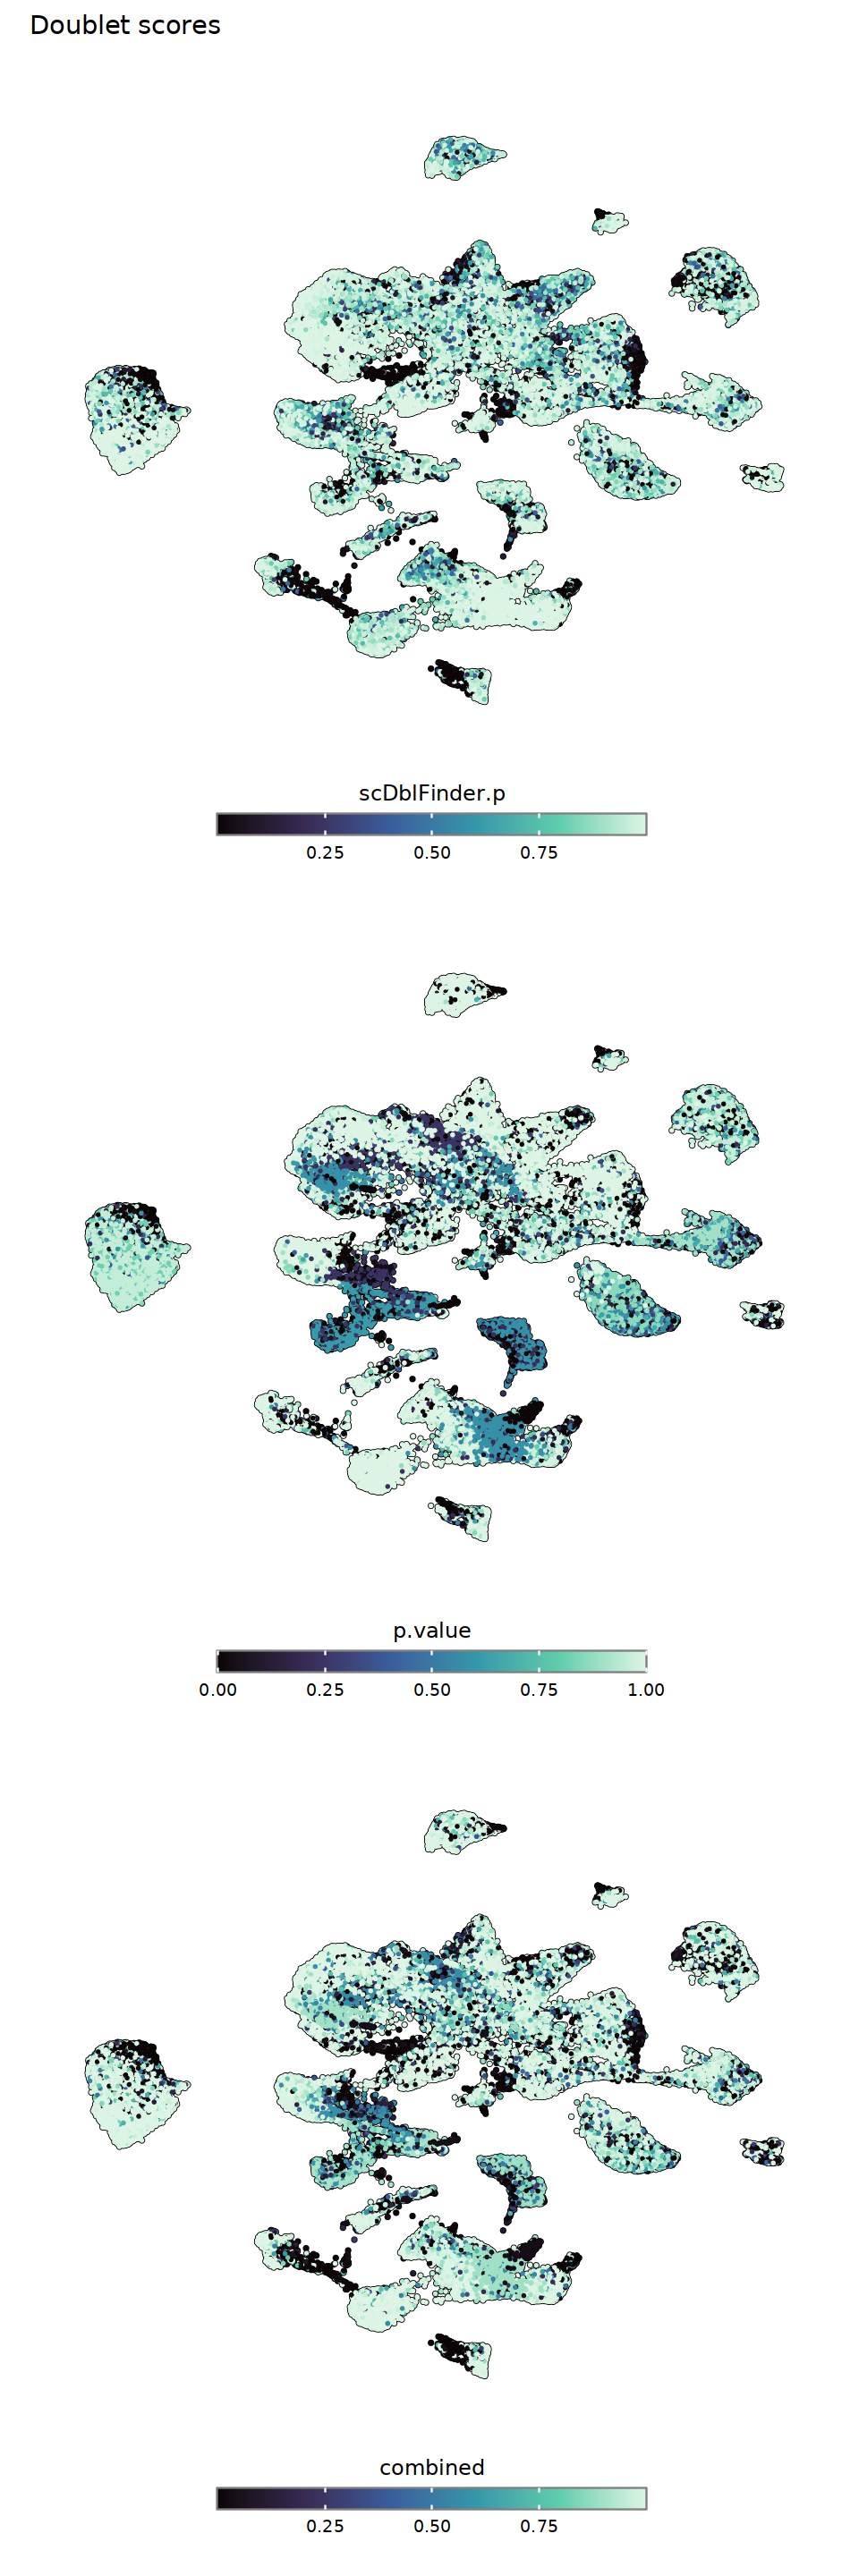

In [8]:
options(repr.plot.height = 24, repr.plot.width = 8)

SCpubr::do_FeaturePlot(integrated, pt.size = 0.5,
                       features = c("scDblFinder.p", "p.value", "combined"), 
                            plot.title = "Doublet scores", 
                            ncol = 1)